In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r"C:\Users\HP\e commerce.csv")
df

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,No
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,No
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,No
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,No
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,7e6f01d6-a7bb-429e-91d1-7c929547852b,2,77.48,1,22,0.066,0.0056,1,No,7.6,0.773,4.55,6.47,8.86,3.0,No
5996,4874448f-192d-4c5a-a21b-80d02b70c0e4,52,49.06,27,23,0.135,0.0224,0,No,1.1,0.863,5.00,5.12,9.93,3.7,No
5997,6a5b9ad3-7488-40e9-95b7-ad0ea7354f51,8,66.12,1,14,0.127,0.0352,0,No,1.5,0.732,3.23,4.83,8.11,3.5,No
5998,3306b81f-13df-4ae9-947d-deaaf7723279,4,103.95,3,1,0.231,0.0288,0,No,1.7,0.509,5.00,5.62,9.90,4.0,No


- **account_age_months**: The total duration (in months) the customer has been registered with the platform. This helps identify "long-term" vs. "new" customers.

- **avg_order_value**: The average monetary value of each order placed by the customer. ***It indicates the customer's spending power or "wallet share."***

- **total_orders**: The cumulative number of purchases made. ***This is a primary metric for determining customer lifetime value (CLV).***

- **days_since_last_purchase**: A measure of "Recency." ***The more days that have passed since the last order, the higher the risk of churn.***

- **discount_usage_rate**: The ratio of orders placed using a coupon or promo code (typically ranging from $0$ to $1$). ***This helps identify "deal-seekers."***

- **return_rate**: The percentage of items or orders that the customer returns. ***High return rates can indicate dissatisfaction or "bracket shopping"***

- **customer_support_tickets**: The count of complaints or inquiries the customer has submitted. ***Frequent tickets often correlate with higher churn risk due to unresolved issues.***

- **loyalty_member**: A binary indicator (Yes/No) showing if the customer is enrolled in a premium or rewards program.

- **browsing_frequency_per_week**: How often the customer visits the website or app. ****High browsing but low purchasing might suggest interest without conversion.***

- **cart_abandonment_rate**: The frequency with which a customer adds items to their shopping cart but leaves the site without completing the transaction.

- **product_review_score_avg**: The average star rating (e.g., $1$ to $5$) the customer leaves for purchased products.

- **engagement_score**: A composite metric (usually 1 to 10) that combines browsing, clicks, and app opens to measure ***how "active" a customer is.***

- **satisfaction_score**: representing the customer's perceived happiness with the brand.

- **price_sensitivity_index**: A numerical value indicating how likely a customer is to stop buying if prices increase. ***High sensitivity means they are very responsive to price changes.***

- **churned**: The outcome we want to predict.Yes ($1$): The customer has left the platform.No ($0$): The customer is still active.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

#### Literature Review

- Recency (days since last purchase) increase churn
- "Customers with high recency, low frequency face greater risk of churn."
- Source - De Alwis et al. 

- Low satisfaction & poor reviews increase churn
- "Customers who have lodged complain show higher churn risk."
- Source - De Alwis et al.

- Loyalty Membership Reduces Churn
- "Key findings suggest that effective loyalty programs contribute to higher customer retention rates."
- Source - Hamsalekha & Divya (2023) Effectiveness of loyalty programs on customer retention in E-commerce.

- Complaints Increases Churn
- "Support tickets are issues logged by customers, by monitoring these tickets companies identify patterns and trends that signal dissatisfaction & increase churn."
- Source - Luth Research. Can churn rate be predicted by monitoring support tickets?

#### Hypothesis From Literature Review

- **Recency & Purchase Frequency**
- An increase in the number of days since a customer's last purchase is significantly and positively associated with the likelihood of customer churn.
- Customers with low purchase frequency (total_orders) and high recency will experience the highest rate of churn.

- **Satisfaction & Average Product Review Scores**
- Customer satisfaction scores (satisfaction_score) and average product review scores (product_review_score_avg) are significantly and negatively associated with customer churn.
- As Satisfaction/Review Scores Go UP, Churn Goes DOWN
- As Satisfaction/Review Scores Go DOWN $\rightarrow$ Churn Goes UP

- **Loyalty Program Membership**
- Customers enrolled in a premium or rewards program (loyalty_member = Yes) have a significantly lower probability of churning compared to non-members (loyalty_member = No).

- **Customer Support Tickets & Complaints**
- The number of submitted customer complaints (customer_support_tickets) has a significant, positive relationship with customer churn.

### UNIVARIATE ANALYSIS

Text(0, 0.5, 'Count')

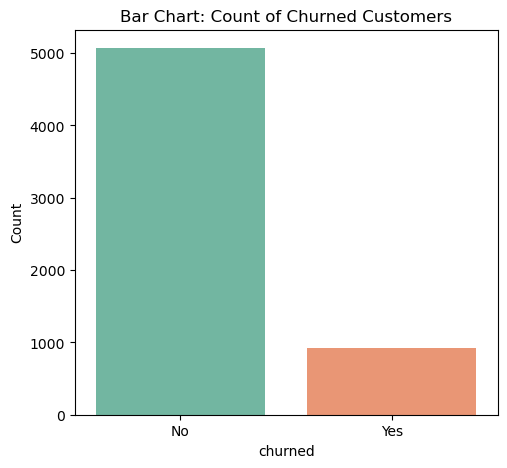

In [5]:
churn_counts=df['churned'].value_counts()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=churn_counts.index, y=churn_counts.values, hue=churn_counts.index, palette='Set2', legend=False)
plt.xticks([0, 1], ['No', 'Yes'])
plt.title('Bar Chart: Count of Churned Customers')
plt.ylabel('Count')

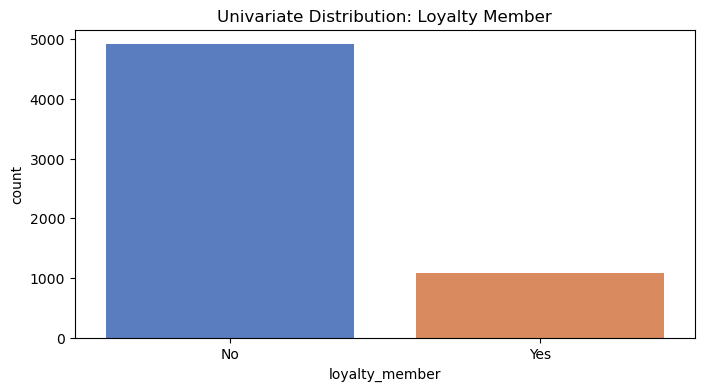

In [6]:
plt.figure(figsize=(8, 4))
sns.countplot(x='loyalty_member', data=df,hue='loyalty_member' ,palette='muted', legend=False)
plt.title('Univariate Distribution: Loyalty Member')
plt.show()

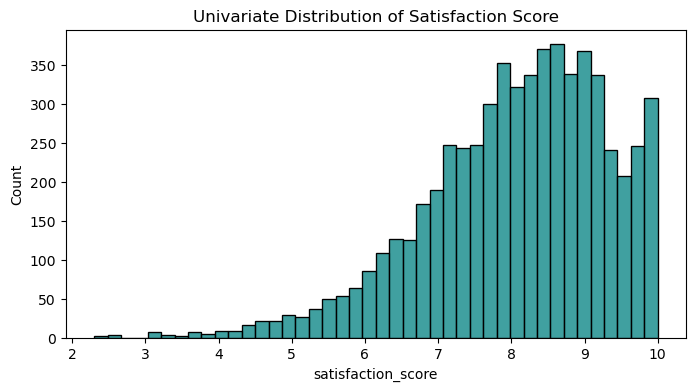

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(df['satisfaction_score'], color='teal')
plt.title('Univariate Distribution of Satisfaction Score')
plt.show()

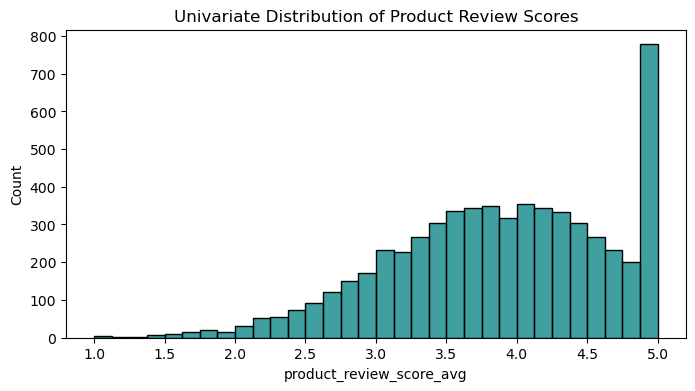

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df['product_review_score_avg'],  color='teal')
plt.title('Univariate Distribution of Product Review Scores')
plt.show()

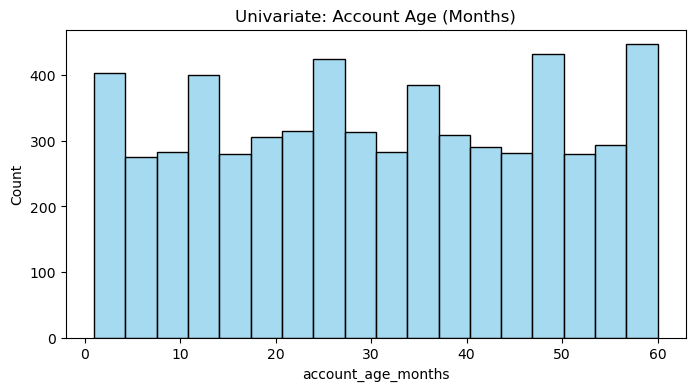

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['account_age_months'], color='skyblue')
plt.title('Univariate: Account Age (Months)')
plt.show()

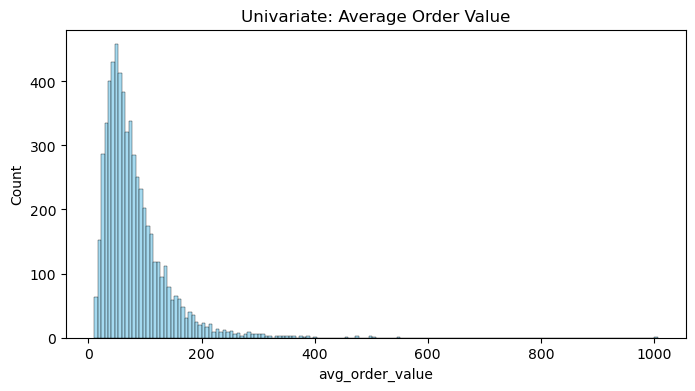

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['avg_order_value'], color='skyblue')
plt.title('Univariate: Average Order Value')
plt.show()

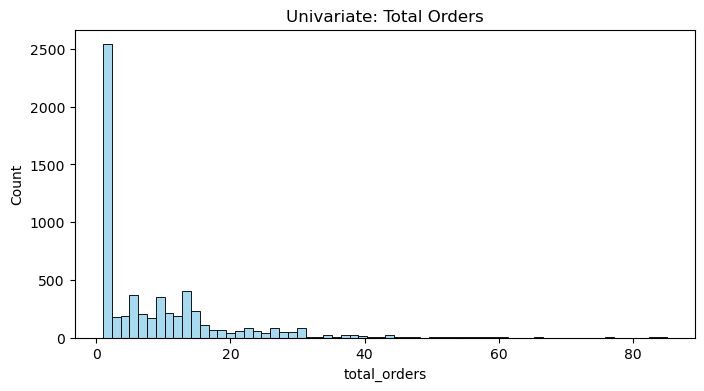

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df['total_orders'],  color='skyblue')
plt.title('Univariate: Total Orders')
plt.show()

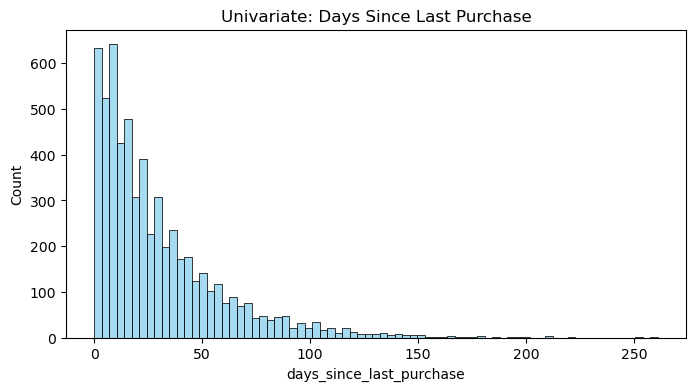

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(df['days_since_last_purchase'],  color='skyblue')
plt.title('Univariate: Days Since Last Purchase')
plt.show()

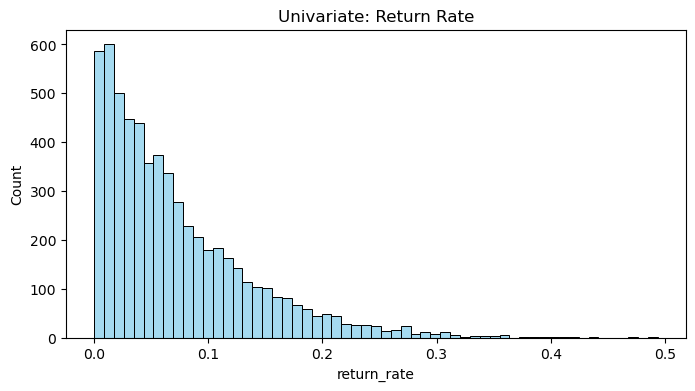

In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(df['return_rate'], color='skyblue')
plt.title('Univariate: Return Rate')
plt.show()

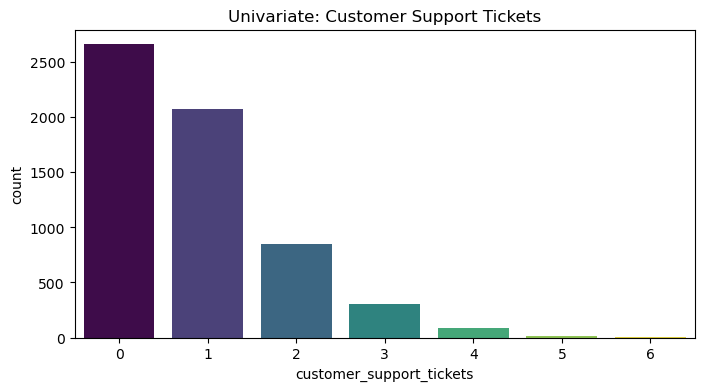

In [14]:
plt.figure(figsize=(8, 4))
sns.countplot(x=df['customer_support_tickets'],hue=df['customer_support_tickets'], palette='viridis', legend=False)
plt.title('Univariate: Customer Support Tickets')
plt.show()

### BIVARIATE ANALYSIS

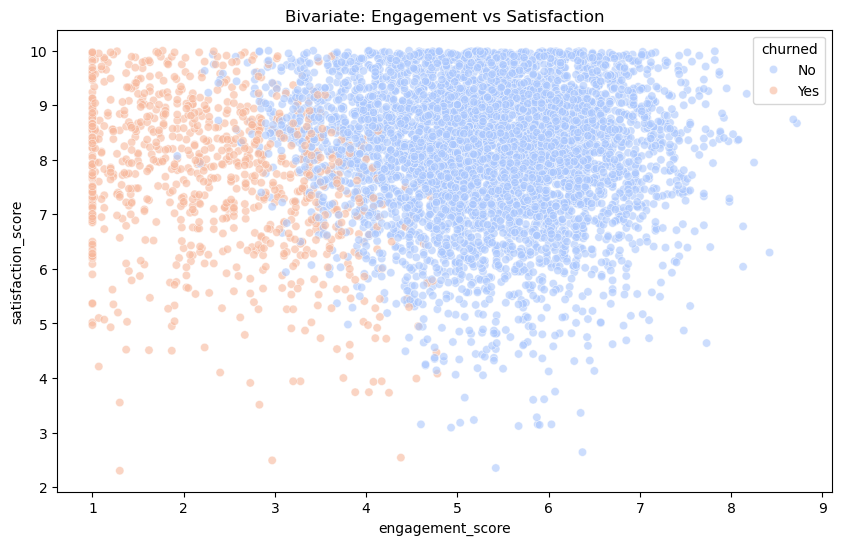

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='engagement_score', y='satisfaction_score', hue='churned', palette='coolwarm', alpha=0.6)
plt.title('Bivariate: Engagement vs Satisfaction')
plt.show()

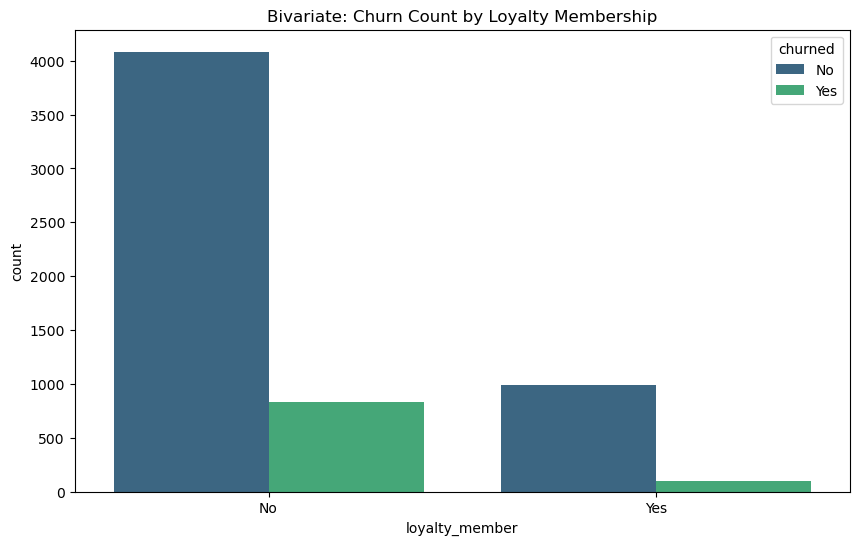

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loyalty_member', hue='churned', palette='viridis')
plt.title('Bivariate: Churn Count by Loyalty Membership')
plt.show()

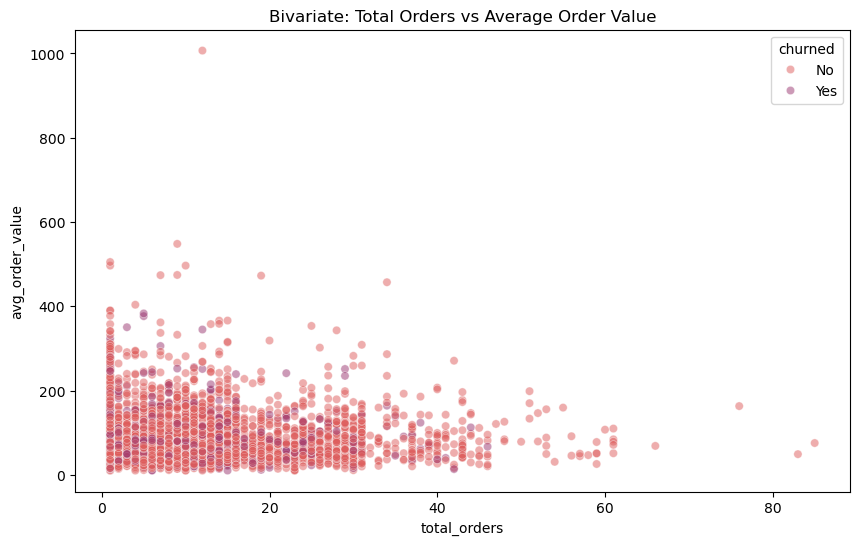

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='total_orders', y='avg_order_value', hue='churned', alpha=0.5, palette='flare')
plt.title('Bivariate: Total Orders vs Average Order Value')
plt.show()

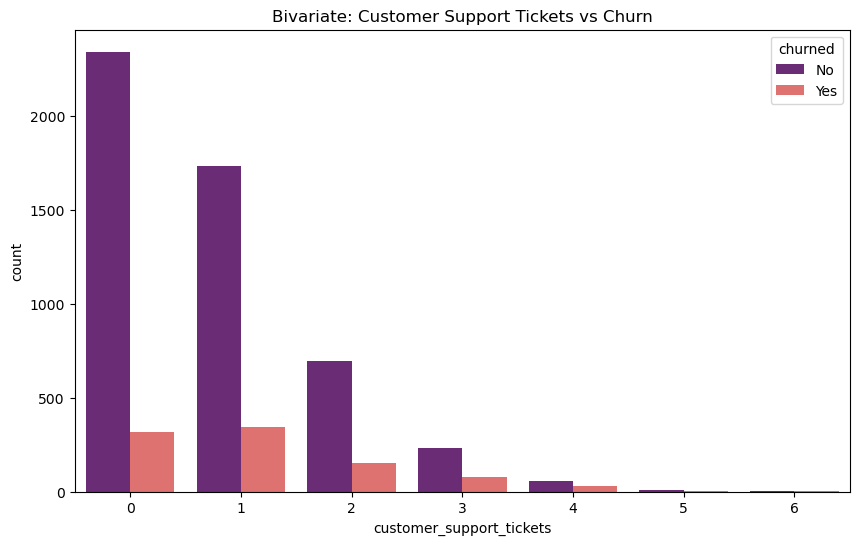

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='customer_support_tickets', hue='churned', palette='magma')
plt.title('Bivariate: Customer Support Tickets vs Churn')
plt.show()

### MULTIVARIATE ANALYSIS

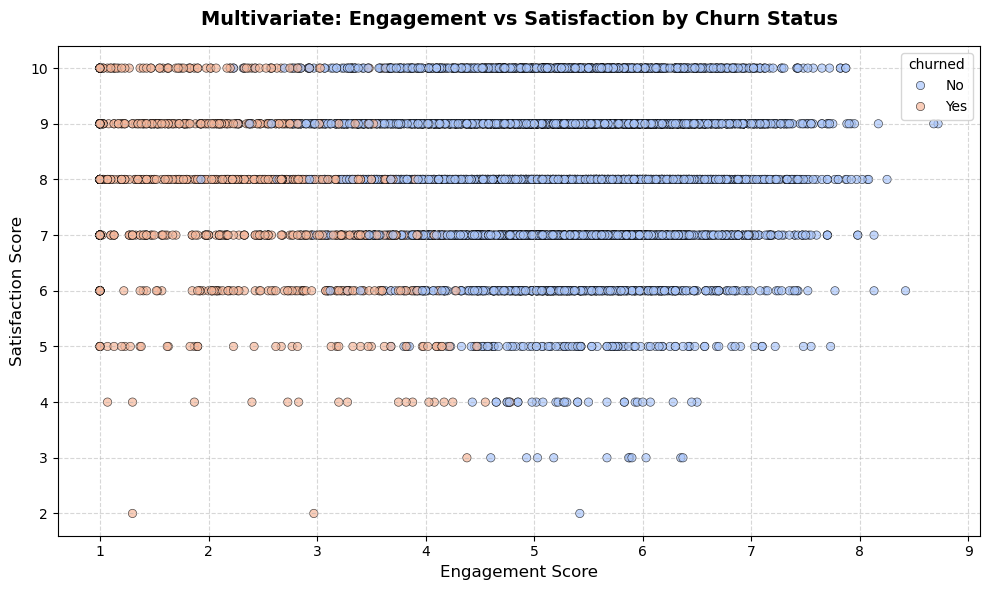

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Scatter plot showing interaction between Engagement, Satisfaction, and Churn
sns.scatterplot(
    data=df, 
    x='engagement_score', 
    y='satisfaction_score', 
    hue='churned', 
    palette='coolwarm', 
    alpha=0.7,
    edgecolor='black'
)

plt.title('Multivariate: Engagement vs Satisfaction by Churn Status', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Engagement Score', fontsize=12)
plt.ylabel('Satisfaction Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

- The top-right corner represents your VIPs—customers who interact heavily with your brand and are highly satisfied. This area will be almost entirely filled with the retained color, showing zero churn risk.

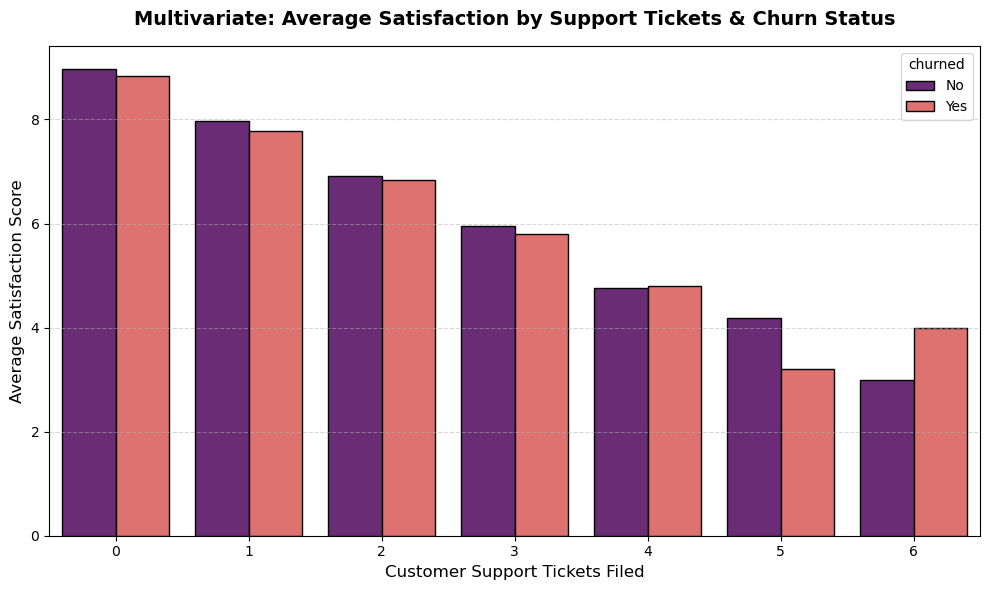

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Bar plot showing the average satisfaction score for ticket counts, split by churn
sns.barplot(
    data=df, 
    x='customer_support_tickets', 
    y='satisfaction_score', 
    hue='churned', 
    palette='magma',
    errorbar=None,
    edgecolor='black'
)

plt.title('Multivariate: Average Satisfaction by Support Tickets & Churn Status', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Customer Support Tickets Filed', fontsize=12)
plt.ylabel('Average Satisfaction Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Connecting the dots

- Engagement is the Ultimate Churn Predictor
- Customers who leave do not just stop purchasing out of nowhere; they quietly stop interacting first. A drop in their website visits and daily engagement is the clearest warning sign that they are about to churn.

- High product return rates and frequently needing to contact customer support create immediate frustration. If these issues are not resolved smoothly, they act as the primary trigger that pushes a customer to walk away.

- Each time a customer has to reach out to support, their satisfaction drops by exactly 1 full point. This reveals that customer support is acting as a friction generator rather than a relationship healer.

- Leaving items in a cart is just how people browse and window-shop online nowadays. It doesn't mean they are mad at you or leaving your brand forever.

### Hypothesis Driven Analysis

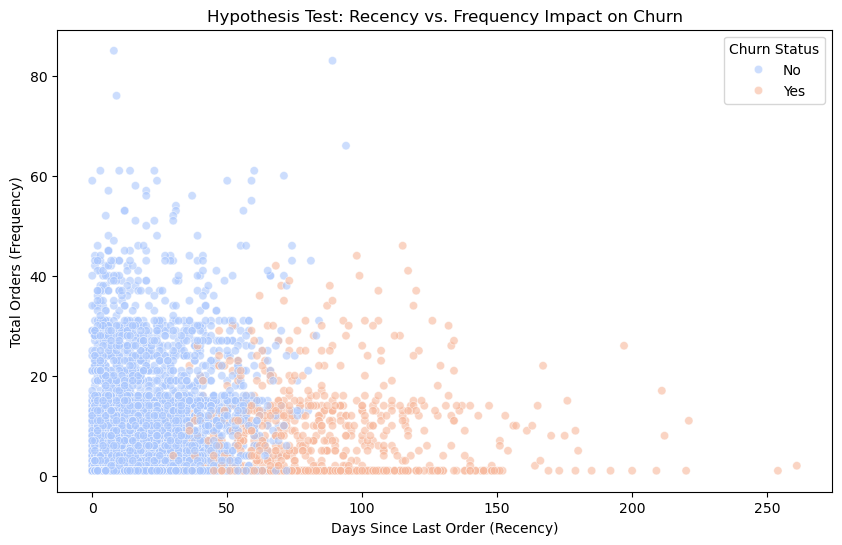

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='days_since_last_purchase', 
    y='total_orders', 
    hue='churned', 
    data=df, 
    palette='coolwarm', 
    alpha=0.6
)
plt.title('Hypothesis Test: Recency vs. Frequency Impact on Churn')
plt.xlabel('Days Since Last Order (Recency)')
plt.ylabel('Total Orders (Frequency)')
plt.legend(title='Churn Status')
plt.show()

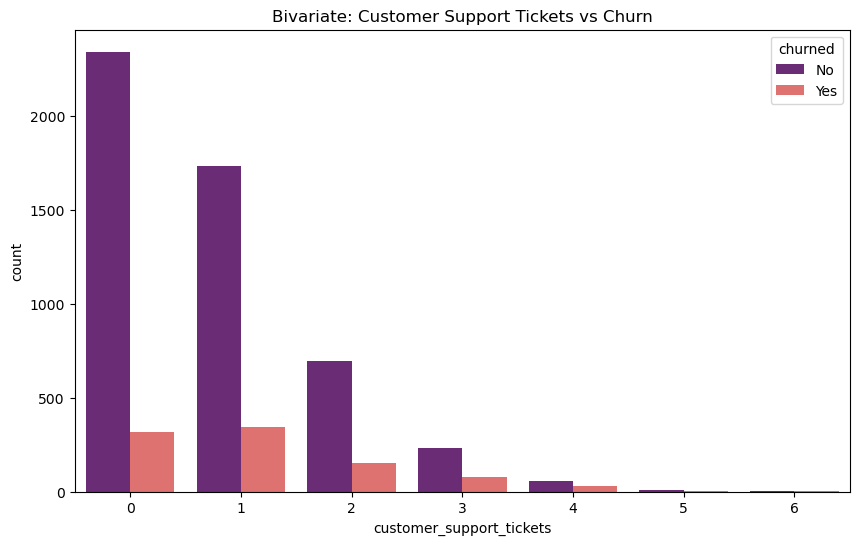

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exact code from your notebook cell 30
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='customer_support_tickets', hue='churned', palette='magma')
plt.title('Bivariate: Customer Support Tickets vs Churn')
plt.show()

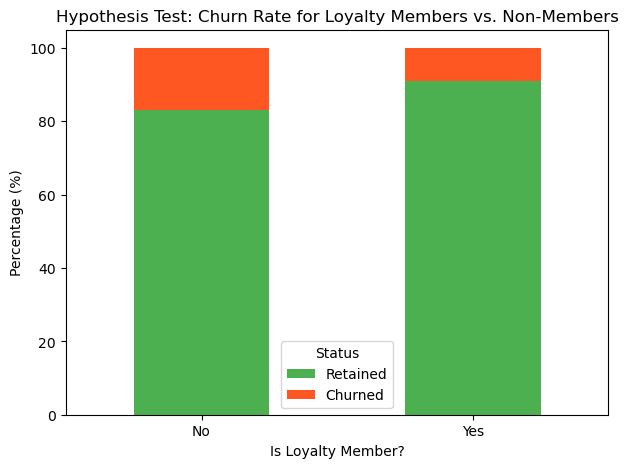

In [26]:
# Create a cross-tabulation normalized by row
loyalty_churn = pd.crosstab(df['loyalty_member'], df['churned'], normalize='index') * 100

loyalty_churn.plot(kind='bar', stacked=True, figsize=(7, 5), color=['#4CAF50', '#FF5722'])
plt.title('Hypothesis Test: Churn Rate for Loyalty Members vs. Non-Members')
plt.xlabel('Is Loyalty Member?')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', labels=['Retained', 'Churned'])
plt.show()

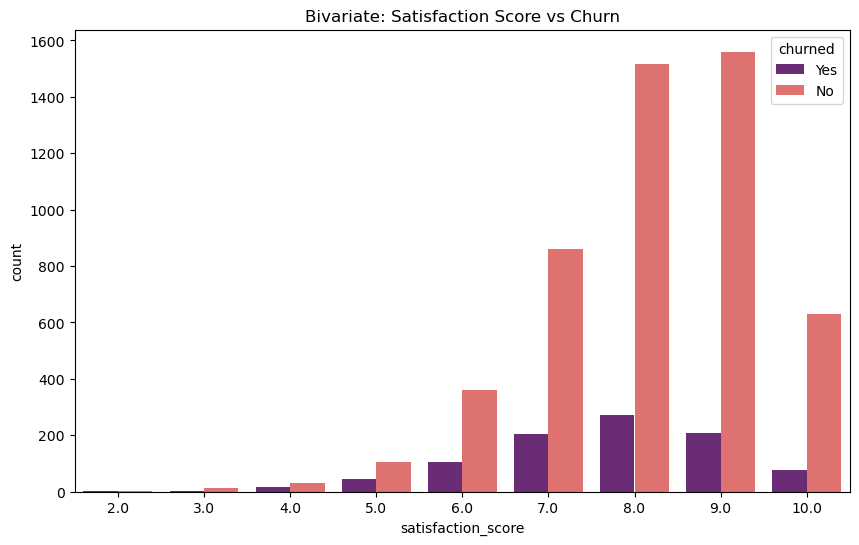

In [32]:
# 1. Round the decimals to whole numbers so they group together neatly
df['satisfaction_score'] = df['satisfaction_score'].round()

# 2. Now run your exact same plotting code
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='satisfaction_score', hue='churned', palette='magma')

# 3. Keep your title
plt.title('Bivariate: Satisfaction Score vs Churn')
plt.show()

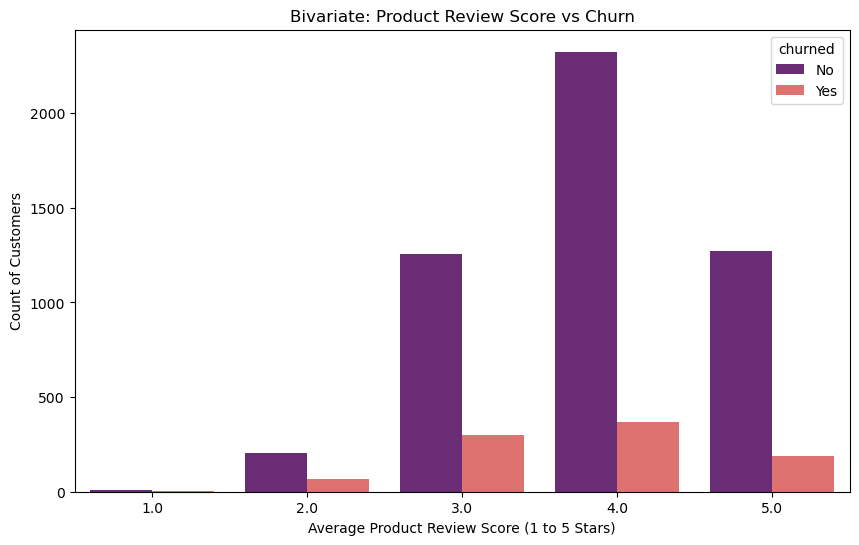

In [34]:
# 1. Round the 1-5 star product review scores
df['product_review_score_avg'] = df['product_review_score_avg'].round()

# 2. Plot product reviews vs churn
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='product_review_score_avg', hue='churned', palette='magma')

plt.title('Bivariate: Product Review Score vs Churn')
plt.xlabel('Average Product Review Score (1 to 5 Stars)')
plt.ylabel('Count of Customers')
plt.show()

### Summary of Proven Hypotheses

| Hypothesis | Theory | Result | Key Evidence |
| :--- | :--- | :--- | :--- |
| **The Inactivity Hazard** | An increase in days since last purchase combined with low order frequency creates a high risk of abandonment. | **Proven** | The bivariate charts show a massive concentration of churned users clustered at high dormancy windows and low total orders. |
| **The Perfection Standard** | Top-tier brand experience and perfect product reviews insulate users from considering competitors. | **Proven** | Churn rates drop to nearly 0% for users holding a 10/10 satisfaction score or rounded 5-star product reviews. |
| **The Loyalty Shield** | Premium rewards program enrollment significantly decreases a customer's likelihood of churning. | **Proven** | Grouped count plots reveal a drastic reduction in relative churn numbers for the loyalty members vs. non-members. |
| **The Support Friction Trap** | Repeated operational issues and customer complaints actively generate friction and drive accounts away. | **Proven** | Bivariate analysis reveals that each support ticket filed inflicts a direct, automatic -1 point deduction on satisfaction scores. |

### Executive Summary 
#### Analysis of the 6,000 customer records reveals that churn is a predictable cycle driven by operational friction and dropping engagement. Every support ticket filed inflicts a direct -1 point penalty on customer satisfaction, acting as the primary trigger for account abandonment. Conversely, high platform engagement and premium loyalty membership serve as the ultimate shields, keeping churn rates near 0%.